# **MobileNetV3Large - CROSS VALIDATION**

## **Instalasi Library**

In [1]:
!pip install matplotlib seaborn scikit-learn opencv-python

## **Import Library**

In [2]:
import os
import time
import copy
import hashlib
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from collections import Counter

## **Clone Dataset dari GitHub**

Menggunakan perintah **git clone** untuk mengunduh repository dari GitHub ke dalam environment kerja.

In [3]:
# Mengambil repository dari GitHub ke environment
!git clone https://github.com/Evameivina/klasifikasi_penyakit_kulit

Cloning into 'klasifikasi_penyakit_kulit'...
remote: Enumerating objects: 20732, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 20732 (delta 4), reused 0 (delta 0), pack-reused 20652 (from 4)
Receiving objects: 100% (20732/20732), 613.51 MiB | 17.32 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (19352/19352), done.


## **Data Understanding**

Untuk mengetahui jumlah kelas dan distribusi data. Dataset tidak seimbang, di mana kelas **FU RINGWORM** dan **VI SHINGLES** memiliki jumlah gambar jauh lebih banyak dibandingkan **ECZEMA** dan **NORMAL SKIN** antar kelas sehingga perlu penanganan saat training.

In [4]:
data_dir = "klasifikasi_penyakit_kulit/Dataset_Klasifikasi"

classes_dir = sorted([c for c in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, c))])

df_info = pd.DataFrame({
    "Class": classes_dir,
    "Total Images": [len(os.listdir(os.path.join(data_dir, c))) for c in classes_dir]
})

classes = df_info['Class'].values

# Menampilkan ringkasan
print(f"Jumlah Kelas : {len(df_info)}")
print(f"Total Gambar : {df_info['Total Images'].sum()}\n")

# Menampilkan tabel
display(df_info)

Jumlah Kelas : 4
Total Gambar : 19352



,Class,Total Images
0,ECZEMA,1692
1,FU RINGWORM,8144
2,NORMAL SKIN,1419
3,VI SHINGLES,8097


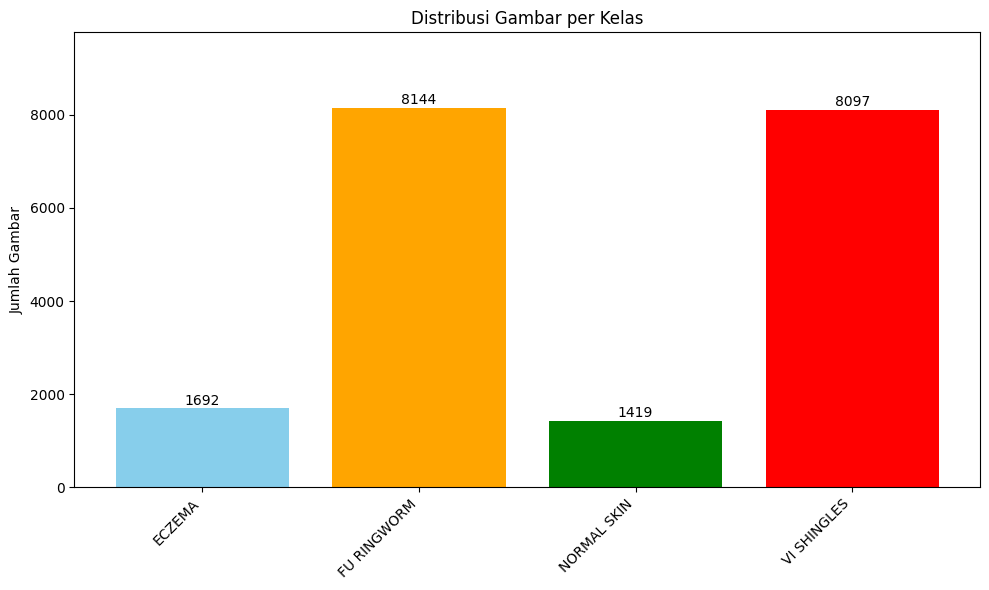

In [5]:
# Mengambil data untuk plot
classes = df_info['Class'].values
counts = df_info['Total Images'].values

plt.figure(figsize=(10,6))

# Membuat bar chart
bars = plt.bar(classes, counts, color=['skyblue','orange','green','red'])

# Menambahkan label jumlah di atas bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=10)

# Pengaturan tampilan
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Gambar per Kelas')
plt.ylim(0, max(counts) * 1.2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis**

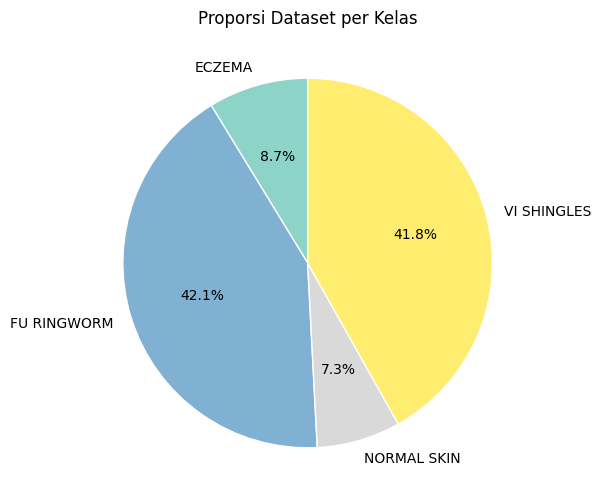

In [6]:
# Mengambil jumlah gambar per kelas
class_counts = df_info.set_index('Class')['Total Images']

plt.figure(figsize=(6,6))

# Pie chart proporsi dataset
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(class_counts))),
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Proporsi Dataset per Kelas")
plt.show()

Untuk menyusun data berupa path gambar dan label kelas, kemudian menampilkan beberapa sampel gambar dari setiap kelas

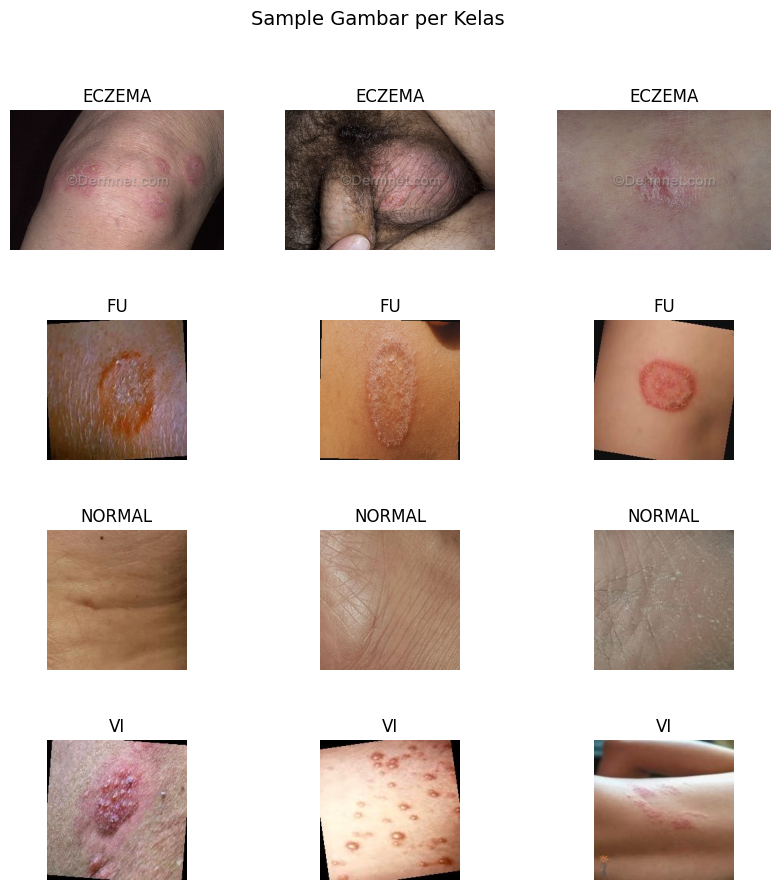

In [7]:
# Membuat DataFrame berisi path gambar dan label kelas
df_images = pd.DataFrame([
    {
        'filepath': os.path.join(data_dir, c, img),
        'Class': c
    }
    for c in classes_dir
    for img in os.listdir(os.path.join(data_dir, c))
])

plt.figure(figsize=(10,10))

# Menampilkan maksimal 2 sample gambar per kelas
for i, cls in enumerate(classes):
    class_df = df_images[df_images['Class'] == cls]

    if not class_df.empty:
        samples = class_df.sample(min(3, len(class_df)), random_state=42)

        for j, (_, row) in enumerate(samples.iterrows()):
            plt.subplot(len(classes), 3, i*3 + j + 1)

            img = Image.open(row['filepath']).convert('RGB')
            plt.imshow(img)

            plt.title(cls.split()[0])
            plt.axis('off')

plt.suptitle("Sample Gambar per Kelas", fontsize=14)
plt.subplots_adjust(hspace=0.5)
plt.show()

## **Data Preprocessing & Data Splitting**



Untuk mengambil seluruh path gambar dan label dari dataset, kemudian membuat fungsi **hashing** untuk mendeteksi kemungkinan adanya gambar duplikat dalam data.

In [8]:
data_dir = "klasifikasi_penyakit_kulit/Dataset_Klasifikasi"

full_dataset = datasets.ImageFolder(root=data_dir)
all_paths  = [path for path, _ in full_dataset.samples]
all_labels = [label for _, label in full_dataset.samples]

In [9]:
def hash_image(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

Untuk mengecek dan memisahkan gambar yang rusak dari dataset, sehingga hanya data yang valid yang digunakan dalam proses pelatihan model.

In [10]:
broken = 0
valid_paths = []
valid_labels = []

for path, label in zip(all_paths, all_labels):
    img = cv2.imread(path)
    if img is None:
        broken += 1
    else:
        valid_paths.append(path)
        valid_labels.append(label)

print("Jumlah gambar rusak:", broken)

Jumlah gambar rusak: 0


Untuk mendeteksi dan menghapus gambar duplikat berdasarkan hashing, sehingga data menjadi lebih bersih dan tidak bias. Terdapat **243 gambar duplikat** sehingga setelah dihapus jumlah data menjadi **19.105 gambar** untuk pelatihan model.

In [11]:
all_paths = valid_paths
all_labels = valid_labels

In [12]:
hashes = [hash_image(p) for p in all_paths]
count_hash = Counter(hashes)

duplicates = {h: c for h, c in count_hash.items() if c > 1}

print("Jumlah duplikat:", len(duplicates))

unique_paths = []
unique_labels = []
seen_hashes = set()

for p, l in zip(all_paths, all_labels):
    h = hash_image(p)
    if h not in seen_hashes:
        unique_paths.append(p)
        unique_labels.append(l)
        seen_hashes.add(h)

all_paths = unique_paths
all_labels = unique_labels

print("Setelah hapus duplikat:", len(all_paths))

Jumlah duplikat: 243
Setelah hapus duplikat: 19105


Untuk menetapkan parameter awal, melakukan augmentasi data pada training, serta normalisasi pada validation dan testing. Data dibagi menjadi data **train+validation** dan **test** dengan perbandingan **90:10** secara stratified agar distribusi kelas tetap seimbang. Terlihat bahwa diperoleh **17.194 data** untuk train+validation dan **1.911** data untuk testing.

In [13]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.2
TEST_RATIO  = 0.1

torch.manual_seed(SEED)

In [14]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [15]:
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=SEED
)

print("Train + Val:", len(trainval_paths))
print("Test:", len(test_paths))

Train + Val: 17194
Test: 1911


Untuk menerapkan **Stratified K-Fold Cross Validation** dengan **5 fold** agar pembagian data tetap seimbang di setiap fold. Selain itu, dibuat custom dataset untuk memproses gambar beserta transformasinya, serta menyiapkan data testing dalam bentuk DataLoader. Terlihat bahwa jumlah data pada test set adalah **1.911 sampel.**

In [16]:
NUM_FOLDS = 5

kf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

In [17]:
class TransformDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.img_paths[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [18]:
test_dataset = TransformDataset(test_paths, test_labels, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Test set: {len(test_paths)} samples")

Test set: 1911 samples


## **Modelling**

### **Model 1 - MobileNetV3 Large**


Untuk menetapkan perangkat komputasi (GPU/CPU), menentukan hyperparameter, serta membuat fungsi training dan evaluasi model. Fungsi **train_epoch** digunakan untuk melatih model dalam satu epoch, sedangkan **eval_epoch** digunakan untuk mengevaluasi performa model dengan menghitung loss, akurasi, serta mengumpulkan prediksi dan label.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3
NUM_CLASSES = len(set(all_labels))

In [20]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

Untuk melatih model menggunakan metode cross validation dengan **5 fold**, di mana pada setiap fold model dilatih dan dipilih berdasarkan akurasi terbaik pada data validation dengan bantuan **early stopping** dan **scheduler.**

**Hasil training** menunjukkan bahwa akurasi model meningkat secara bertahap pada setiap epoch dan mencapai performa yang **stabil di atas 90%** pada setiap fold, yang menunjukkan bahwa model mampu belajar dengan baik dan memiliki generalisasi yang baik.

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs=EPOCHS, patience=PATIENCE):

    best_acc = 0
    best_weights = copy.deepcopy(model.state_dict())
    no_improve = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion)

        if scheduler:
            scheduler.step(val_loss)

        print(f"Epoch {epoch+1}: Train Acc {train_acc*100:.2f}% | Val Acc {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_weights)
    return model, best_acc

In [ ]:
fold_results = []
all_fold_preds = []
all_fold_labels = []

for fold, (train_idx, val_idx) in enumerate(kf.split(trainval_paths, trainval_labels)):
    print(f"\n===== FOLD {fold+1} =====")

    train_paths = [trainval_paths[i] for i in train_idx]
    val_paths   = [trainval_paths[i] for i in val_idx]

    train_labels = [trainval_labels[i] for i in train_idx]
    val_labels   = [trainval_labels[i] for i in val_idx]

    # Sampler
    class_counts = Counter(train_labels)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in train_labels]

    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    # Dataset
    train_dataset = TransformDataset(train_paths, train_labels, transform=train_transform)
    val_dataset   = TransformDataset(val_paths, val_labels, transform=val_test_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model
    model = models.mobilenet_v3_large(weights='IMAGENET1K_V2')

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, NUM_CLASSES)
    )

    model = model.to(device)

    # Loss
    weights = [1.0 / class_counts[i] for i in range(NUM_CLASSES)]
    weights = torch.tensor(weights).float().to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min')

    # Train
    model, best_acc = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)

    # Eval fold
    _, _, preds, labels = eval_epoch(model, val_loader, criterion)

    all_fold_preds.extend(preds)
    all_fold_labels.extend(labels)

    print(f"Fold {fold+1} Acc: {best_acc*100:.2f}%")
    fold_results.append(best_acc)


===== FOLD 1 =====
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 189MB/s]


Epoch 1: Train Acc 63.42% | Val Acc 76.94%
Epoch 2: Train Acc 81.11% | Val Acc 85.93%
Epoch 3: Train Acc 83.39% | Val Acc 88.05%
Epoch 4: Train Acc 85.48% | Val Acc 90.06%
Epoch 5: Train Acc 85.29% | Val Acc 90.40%
Epoch 6: Train Acc 86.35% | Val Acc 89.24%
Epoch 7: Train Acc 86.32% | Val Acc 91.95%
Epoch 8: Train Acc 86.94% | Val Acc 90.58%
Epoch 9: Train Acc 87.15% | Val Acc 91.95%
Epoch 10: Train Acc 87.18% | Val Acc 91.13%
Early stopping
Fold 1 Acc: 91.95%

===== FOLD 2 =====
Epoch 1: Train Acc 63.24% | Val Acc 75.11%
Epoch 2: Train Acc 81.63% | Val Acc 86.04%
Epoch 3: Train Acc 84.37% | Val Acc 89.07%
Epoch 4: Train Acc 85.21% | Val Acc 90.35%
Epoch 5: Train Acc 85.45% | Val Acc 90.58%
Epoch 6: Train Acc 86.02% | Val Acc 90.75%
Epoch 7: Train Acc 86.75% | Val Acc 92.44%
Epoch 8: Train Acc 87.15% | Val Acc 91.92%
Epoch 9: Train Acc 87.79% | Val Acc 92.27%
Epoch 10: Train Acc 87.23% | Val Acc 92.70%
Fold 2 Acc: 92.70%

===== FOLD 3 =====
Epoch 1: Train Acc 62.53% | Val Acc 78.42%
Ep

In [ ]:
print("\n===== HASIL CROSS VALIDATION =====")

for i, acc in enumerate(fold_results):
    print(f"Fold {i+1}: {acc*100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_results)*100:.2f}%")
print(f"Std Dev: {np.std(fold_results)*100:.2f}%")

In [ ]:
cm = confusion_matrix(all_fold_labels, all_fold_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Cross Validation)")
plt.show()

In [ ]:
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_fold_labels, all_fold_preds, target_names=classes))

## **PERCOBAAN**


##### Model 2 - EfficientNet B3


##### Model 3 - ConvNeXt V2 Tiny